## Funcionamento Básico de um hodoscópio

O objetivo de um hodoscópio é registrar a passagem de partículas e permitir a determinação \
de 
suas trajetórias, seja para caracterizar algo situado dentro do arranjo experimental ou fora dele.

__________________________________________________________________________________________________________________
<img src="Hod1.png" alt="Hod1" width="500"/>


__________________________________________________________________________________________________________________ 
Para isso o primeiro passo é ser capaz de determinar a posição de passagem da partícula em cada RPC.

A convenção utilizada para a numeração das pads, considerando a perspectiva de alguém acima da RPC, está diagramada na seguinte imagem:
__________________________________________________________________________________________________________________
<img src="rpcnumb.png" alt="Hod1" width="300"/>

__________________________________________________________________________________________________________________

O canto inferior é o lado onde ficam os conectores de gás e HV da RPC.

Note que o número das pads cresce por 1 de uma linha para a próxima (de baixo pra cima) e por 8 de uma coluna para a próxima (da esquerda pra direita)


# Desafio 1:

Crie uma função que retorne a linha e coluna de uma pad cujo número foi dado.


In [23]:
def getlineandcol(Npad):
    col=((Npad-1)//8)+1 
    line=(Npad-1)%8+1
    return line, col   

Teste rodar a função `getlineandcol()` mudando o número da pad passada para a função, verifique se o resultado está de acordo com o esperado de acordo com o mapa acima

In [24]:
print (getlineandcol(12))

(4, 2)


Como não sabemos onde em uma pad uma partícula passou, utilizamos como referência seu centro. 
Assim sendo, precisamos calcular a posição correspondente a cada pad.
__________________________________________________________________________________________________________________

# Desafio 2:

Considerando um sistema de coordenadas que começa em 0,0 no canto inferior esquerdo da imagem acima, e que as dimensões de cada pad são Lx (no sentido horizontal) e Ly (no sentido vertical), crie uma função que retorne as coordenadas x,y da posição do centro de uma pad cujo número foi dado.

Ps.: Ignore a existência da separação entre as pads, aqui se considera que não há espaço nenhum entre as pads.

In [25]:
Lx = 15.0 #cm
Ly = 19.0 #cm

def getpos (Npad):
    line,col= getlineandcol(Npad)
    xpos=(col-0.5)*Lx
    ypos=(line-0.5)*Ly
    return xpos,ypos

Teste rodar a função `getpos()` mudando o número da pad passada para a função, verifique se os resultados estão dentro das dimensões da RPC (120x152 cm)

In [26]:
print(getpos(64))

(112.5, 142.5)


## Determinação das trajetórias

Agora, iremos calcular as trajetórias dos múons, para que possamos calcular as distribuições angulares do fluxo de múons.  

Para isso, iremos usar os dados das posições em que passaram na RPC inferior e superior e calcular sua trajetória, que é retilínea.

<b>Mas, precisamos entender uma coisa</b>: Nos interessa saber o volume de partículas <b>vindo</b> de cada direção; se um grande número de partículas viajando da direção leste para oeste nos atinge, dizemos que o fluxo na direção <b>leste</b> é grande.
    
 
Isso significa que iremos tratar como se os múons estivessem se propagando no sentido oposto ao que atingem nosso setup, representando-os como uma reta se originando na RPC inferior e saindo pela RPC superior.
 
Para caracterizar essas retas, usaremos o sistema horizontal de coordenadas, onde uma direção é descrita por dois ângulos: o ângulo **azimutal** ($\phi$) e o ângulo **zenital** (\$\theta$), conforme descrito na imagem:

__________________________________________________________________________________________________________________
<img src="hod2.png" alt="Hod1" width="500"/>

__________________________________________________________________________________________________________________


# Desafio 3

Escreva uma função onde, dadas as dimensões H, Lx, Ly e os números das pads que a partícula ativou em cada RPC (inferior e superior), retorne o ângulo azimutal e o ângulo zenital que </b> aponta pra direção de vinda da partícula</b> ().

Ps.: Note que aqui que, para a determinação destes ângulos, não interessa a posição absoluta em que passou em cada RPC, apenas as diferenças.



In [27]:
H = 37.2 #cm

from math import sin, cos, tan, sqrt, atan, asin, log10, pi, floor, ceil
from matplotlib import pyplot as plt
import numpy as np 


def calcangles(Npadinf,Npadsup):
    ysup,xsup= getlineandcol(Npadsup)
    yinf,xinf= getlineandcol(Npadinf)
    deltaX=(xsup-xinf)*Lx
    deltaY=(ysup-yinf)*Ly
    diag = sqrt(deltaX**2.0+deltaY**2.0)
    zen=180.0*atan(diag/H)/pi
    if(diag > 0.0):
        azi = asin(deltaY/diag)
        if (deltaX) >= 0.0:
            azi = pi - azi
        if azi < 0.0 and (deltaX) < 0.0:
            azi = 2*pi + azi
        azi=180*azi/pi
    else:
        azi=0.0
    return azi,zen

Teste rodar a função `calcangles()` com diferentes valores de Npadsup e Napinf. Os ângulos azimutais e zenitais fazem sentido de acordo com a figura acima?

In [28]:
calcangles(8,1)

(270.0, 74.37373384569399)

## O output: visualizando nossos resultados

Finalmente, podemos juntar tudo que fizemos até aqui para analisar um arquivo de dados real. 
Precisamos apenas aprender a organizar nossos resultados de modo que possamos visualizá-los, analisá-los e apresentá-los a nossos pares na comunidade acadêmica. Para isso, vamos utilizar as bibliotecas `matplotlib` e `numpy`.

Comecendo lendo o arquivo binário de uma aquisição real de 5 milhões de eventos.

Neste arquivo há sinais de 3 RPCs do evento. Cada evento consiste apenas de 3 bytes, o primeiro byte tendo o número da pad na qual o múon passou na RPC inferior, o segundo sendo da RPC acima logo desta, e o terceiro sendo da RPC superior.

Porém, só estamos interessados na inferior e na superior.

## Bloco 1 ↓

In [29]:


def getevts(arquivo):
    Pads_inf,Pads_sup=[],[]
    binario=open(arquivo, 'rb')   #lê o arquivo binário com os dados
    array = np.fromfile(binario, dtype=np.uint8) #array para o qual os bytes do arquivo serão lidos
    tamanho=len(array)  #tamanho do array lido
    indice=0 #indice usado para varrer o array
    while(indice<tamanho):     #converte os dados para inteiros e adiciona nos arrays.
        Pads_inf.append(int(array[indice]))  #aqui está a pad que foi ativada da RPC inferior
        Pads_sup.append(int(array[indice+2]))  #aqui está a pad que foi ativada da RPC superior
        indice+=4
    return Pads_inf,Pads_sup #retorna dois arrays, um com os números das pads inferiores, outro das superiores

Pads_inf,Pads_sup = getevts('EAFEXP_EAFEXP2025_SUBSOLO.bin') #lê o binário

Agora, inspecione o conteúdo desses arrays executando a célula abaixo. Há algo que não esperava?

In [30]:
Pads_inf
Pads_sup

[16,
 29,
 55,
 53,
 42,
 8,
 51,
 41,
 52,
 46,
 34,
 62,
 54,
 56,
 39,
 37,
 9,
 65,
 35,
 5,
 40,
 54,
 60,
 64,
 50,
 30,
 26,
 3,
 12,
 34,
 44,
 29,
 39,
 32,
 50,
 6,
 26,
 54,
 35,
 27,
 65,
 49,
 17,
 52,
 43,
 0,
 24,
 65,
 20,
 54,
 13,
 30,
 16,
 55,
 38,
 43,
 6,
 12,
 13,
 49,
 62,
 1,
 18,
 24,
 16,
 1,
 12,
 51,
 21,
 27,
 63,
 7,
 22,
 18,
 34,
 47,
 46,
 13,
 5,
 8,
 31,
 0,
 13,
 18,
 37,
 65,
 2,
 29,
 35,
 20,
 13,
 44,
 15,
 53,
 27,
 32,
 7,
 3,
 36,
 15,
 49,
 37,
 62,
 4,
 50,
 61,
 59,
 54,
 20,
 47,
 5,
 19,
 0,
 20,
 26,
 27,
 31,
 12,
 65,
 2,
 44,
 12,
 40,
 27,
 0,
 38,
 18,
 61,
 15,
 18,
 42,
 5,
 19,
 0,
 47,
 27,
 51,
 22,
 27,
 14,
 3,
 39,
 25,
 49,
 3,
 0,
 54,
 18,
 45,
 59,
 29,
 45,
 61,
 40,
 31,
 13,
 36,
 20,
 23,
 46,
 11,
 37,
 15,
 27,
 65,
 45,
 21,
 19,
 54,
 16,
 32,
 23,
 14,
 30,
 49,
 31,
 33,
 32,
 45,
 39,
 50,
 45,
 46,
 39,
 20,
 46,
 27,
 19,
 55,
 50,
 10,
 27,
 13,
 15,
 18,
 43,
 12,
 26,
 47,
 6,
 23,
 29,
 56,
 45,
 12,
 6

Talvez você tenha notado o valor 65 ou mesmo 0 nos dados, sendo que as pads vão de 1 a 64. 

A valor <b>0</b> indica que não houve sinal em nenhuma pad naquela RPC (o que é possível dependendo da condição da coincidência), enquanto o valor <b>65</b> indica que houve sinal em mais de uma pad (da mesma RPC), o que impossibilita a localização da passagem da partícula naquela RPC.

Vamos então excluir eventos onde algum desses números aparecem:

## Bloco 2 ↓

In [31]:
validinf=[]
validsup=[]
for i in range(len(Pads_inf)): #índice para varrer os arrays com os dados lidos do arquivo 
    if(0<Pads_inf[i]<65 and 0<Pads_sup[i]<65): #Verifica se são diferentes de 0 e 65
        validinf.append(Pads_inf[i])
        validsup.append(Pads_sup[i])  
        
#podemos agora limpar a memória dos dados brutos

import gc #importa o coletor de lixo do python
del Pads_inf, Pads_sup
gc.collect()

1157

Matenha em mente que os arrays com os dados de eventos válidos agora são "validinf" e "validsup".

Com eles agora, nós vamos criar alguns arrays auxiliares, com números de linhas, colunas, e ângulos dos eventos, para nossas visualizações:

## Bloco 3 ↓

In [32]:
azimutal, zenital = [], [] #dois arrays para os ângulos
lines_inf, cols_inf = [], [] #dois arrays para as colunas e linhas das pads de cada evento da RPC inferior
lines_sup, cols_sup = [], [] #mesma coisa mas para a RPC superior

for i in range(len(validsup)):
    Nsup=validsup[i]
    Ninf=validinf[i]
    azi,zen=calcangles(Ninf,Nsup) #calcula os ângulos 
    zenital.append(zen)
    if(zen!=0):
        azimutal.append(azi)  #não adiciona o azimute se o zênite for zero, pois é indefinido
    lineinf,colinf=getlineandcol(Ninf) 
    linesup,colsup=getlineandcol(Nsup)
    lines_inf.append(lineinf)
    lines_sup.append(linesup)
    cols_inf.append(colinf)
    cols_sup.append(colsup)

#Agora vamos criar histogramas para a visualização e análise dos dados 

infhist=np.array((np.histogram(validinf,64,(0.5,64.5)))[0],dtype=float) #histograma de pads inferiores 
suphist=np.array((np.histogram(validsup,64,(0.5,64.5)))[0],dtype=float) #''        ''   ' '  superiores
azihist=np.array((np.histogram(azimutal,361,(-0.5,360.5)))[0],dtype=float) #histograma de angulos azimutais
zenhist=np.array((np.histogram(zenital,91,(-0.5,90.5)))[0],dtype=float)  #  ''       ''   ''    zenitais
inf2d=np.array((np.histogram2d(lines_inf,cols_inf,8,[[0.5,8.5],[0.5,8.5]]))[0],dtype=float) #histograma 2D para mapa de calor da RPC inferior
sup2d=np.array((np.histogram2d(lines_sup,cols_sup,8,[[0.5,8.5],[0.5,8.5]]))[0],dtype=float) #histograma 2D para mapa de calor da RPC superior
bins64 =  [i+1 for i in range(64)] #os arrays abaixo contém o valor dos bins pros histogramas
bins90 =  [i for i in range(91)]
bins360 = [i for i in range(361)]
bins8=    [i+1 for i in range(8)]

Agora, podemos produzir *plots* das distribuições de contagens em função do número da *pad* em cada uma das RPCs de maneira bastante simples:

## Bloco 4 ↓

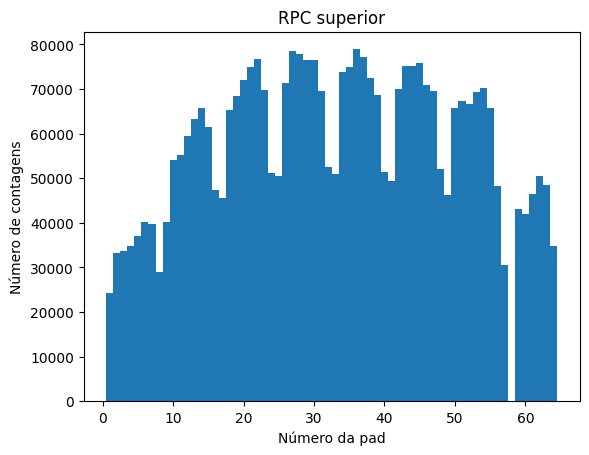

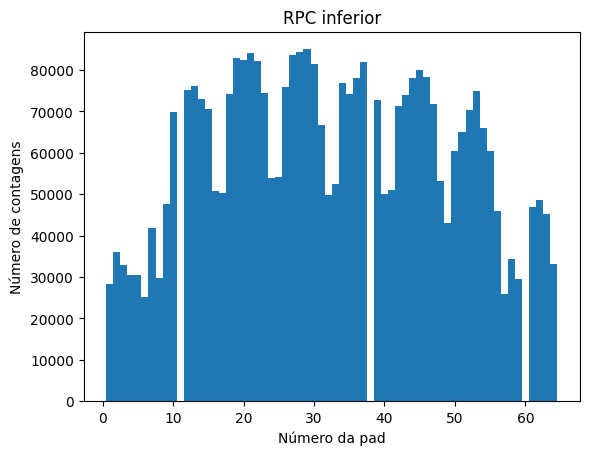

In [33]:
plt.bar(bins64,suphist,width=1)
plt.ylabel("Número de contagens")
plt.xlabel("Número da pad")
plt.title("RPC superior")
plt.show()

plt.bar(bins64,infhist,width=1)
plt.ylabel("Número de contagens")
plt.xlabel("Número da pad")
plt.title("RPC inferior")
plt.show()

Podemos ver ainda a distribuição de eventos em 2D ao longo da RPC, como quem vê a RPC de cima. Nesse caso teremos um mapa de cores, indicado no eixo z, com o número de contagens em cada pad. Para os *plots* abaixo, uma cor mais clara indica menos eventos, enquanto uma cor mais vermelha e escura indica mais eventos.

## Bloco 5 ↓


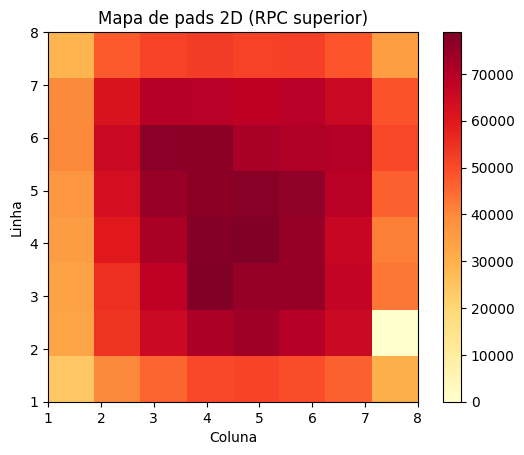

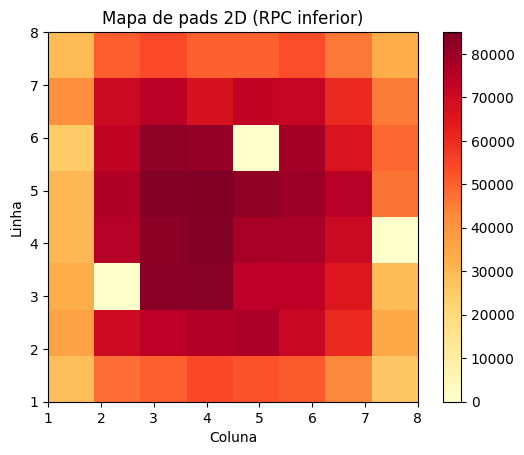

In [34]:


plt.imshow(sup2d, cmap="YlOrRd", interpolation='none', origin="lower", extent=[1, 8, 1, 8])
plt.colorbar()
plt.xlabel("Coluna")
plt.ylabel("Linha")
plt.xticks(np.arange(1, 9, step=1))
plt.yticks(np.arange(1, 9, step=1))
plt.title("Mapa de pads 2D (RPC superior)")
plt.show()


plt.imshow(inf2d, cmap="YlOrRd", interpolation='none', origin="lower", extent=[1, 8, 1, 8])
plt.colorbar()
plt.xlabel("Coluna")
plt.ylabel("Linha")
plt.xticks(np.arange(1, 9, step=1))
plt.yticks(np.arange(1, 9, step=1))
plt.title("Mapa de pads 2D (RPC inferior)")
plt.show()


Vamos agora ver as distribuições em função dos ângulos azimutal e zenital. O que você espera da aparência dessas distribuições?

## Bloco 6 ↓

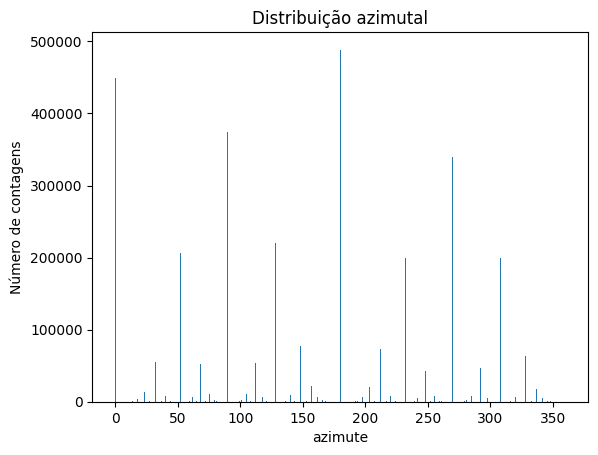

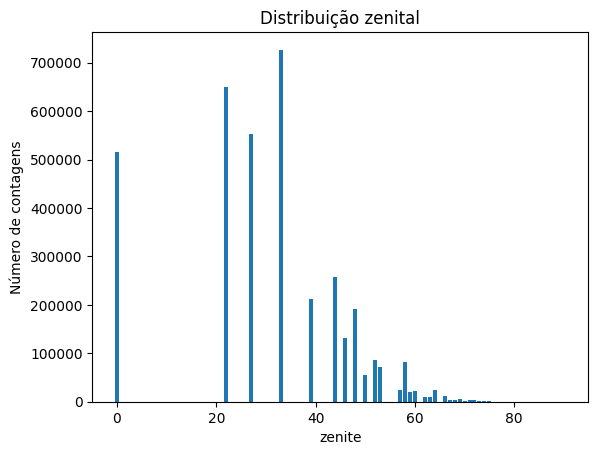

In [35]:
plt.bar(bins360,azihist,linewidth=10)
plt.ylabel("Número de contagens")
plt.xlabel("azimute")
plt.title("Distribuição azimutal")
plt.show()

plt.bar(bins90,zenhist,linewidth=10)
plt.ylabel("Número de contagens")
plt.xlabel("zenite")
plt.title("Distribuição zenital")
plt.show()

Também será útil, mais tarde, que tenhamos o erro associado a cada bin desses gráficos acima, que, assim como no caso do fluxo, sendo eventos aleatórios, tem um erro de raiz de N:

## Bloco 7 ↓

In [36]:
errazi=[] #cria array pra salvar os erros de cada bin do histograma de zênite
for i in azihist: 
    errazi.append(sqrt(i))

errzen=[] #cria array pra salvar os erros de cada bin do histograma de azimute
for i in zenhist:
    errzen.append(sqrt(i))

Vamos agora fazer um backup desses histogramas, para usarmos mais tarde, e limpar os arrays usados:

## Bloco 8↓

In [37]:
# infhist_data=infhist.copy() #copia arrays
# suphist_data=suphist.copy()
# azihist_data=azihist.copy()
# zenhist_data=zenhist.copy()
# inf2d_data=inf2d.copy()
# sup2d_data=sup2d.copy()
# errazi_data=errazi.copy()
# errzen_data=errzen.copy()

# del lines_inf,lines_sup,cols_inf,cols_sup,infhist,suphist,azihist,zenhist,inf2d,sup2d,errazi,errzen,validsup,validinf,azimutal,zenital

# gc.collect() 


O que acharam destes resultados?

Conseguem entender a lógica por trás dos padrões?

Uma das coisas que pode ter observado nos dados é que os histogramas dos ângulos são extremamente falhos e descontínuos, com picos em virtude da geometria do experimento e da consideração de que todas partículas passam pelo centro das pads.

Precisamos agora encontrar uma forma de ver nestes dados o que é intrínseco do fluxo de múons e o que é afetado da análise e reconstrução.

Então, que tal analizarmos a resposta que este hodoscópio teria a um fluxo angularmente uniforme de múons?

#### Mas, o que é um fluxo uniforme?

## Fluxo uniforme


Um fluxo uniforme seria um fluxo que, além de invariante com a translação, seria também invariante com a rotação. Oriente uma superfície plana de qualquer maneira, e você receberá o mesmo fluxo.

Uma maneira de raciocinar sobre este fluxo é imaginar que está no centro de uma semiesfera, e que os raios atravessando a esfera formam sobre esta um conjunto de pontos uniformemente distribuídos em sua superfície.


__________________________________________________________________________________________________________________
<img src="unif.png" alt="Hod1" width="500"/>

__________________________________________________________________________________________________________________

# Desafio 4 

Com base nesse raciocínio, proponha uma distribuição de probabilidade para o zênite e outra para o azimute de forma que, sorteando-os independentemente, cada qual seguindo sua respectiva distribuição de probabilidade, resulte em um fluxo uniforme.

__________________________________________________________________________________________________________________

Uma vez que tiver proposto as distribuições de probabilidade, escreva um código, seguindo o método monte-carlo, que sorteie o azimute e o zênite de uma distribuição uniforme: 

In [38]:
def sortuniform():
    while True:
        zen = np.random.rand()*pi/2.0 #zenite indo de 0 até 90°
        likelihoodzen = sin(zen)
        test = np.random.rand()
        if(test<likelihoodzen):
            break
    azi = np.random.rand()*2*pi #zenite indo de 0 até 360°
    return azi,zen

# Hodoscópio simulado

Agora que sabemos como gerar um fluxo uniforme, nós podemos combinar essa função com algumas mais funções para simular nosso hodoscópio sob este fluxo uniforme de múons, assumindo 100% de eficiência eletrônica para as vivas.

## Bloco 9 ↓

In [39]:
from numpy import random

H1=6.2
H2=37.2
H3=43.4

def getnpad(x,y):         #pega o número da pad de acordo com a coordenada x,y, retornando 0 se não estiver na RPC
    if(0<=x<=120.0 and 0<=y<=152.0):   
        if(x==120.0):
            line=8
        else:
            line=y//Ly+1
        if(y==152.0):
            col=8
        else:
            col=x//Lx+1
        return (col-1)*8+line
    else:
        return 0

def sortpos():             #sorteia aleatoriamente uma posição na RPC superior
    xsort=np.random.rand()*Lx*8
    ysort=np.random.rand()*Ly*8
    return xsort,ysort
    
def calcposinf(x_sup,y_sup,zen,azi,H): #propaga o raio de acordo com a posição inicial, zenite e azimute
        zen_tan=tan(zen)           
        slopex=cos(azi)*zen_tan
        slopey=sin(azi)*zen_tan
        x_inf=x_sup+slopex*H
        y_inf=y_sup+slopey*H
        return x_inf,y_inf

    
def simu(Nevts,Pads_inf,Pads_sup): #simula a RPC
    ievt=0
    while(ievt<Nevts):                #garante o núemro de eventos pedidos
       #verifica se o evento é valido
        x_sup,y_sup=sortpos()     #sorteia posição na RPC superior
        azi,zen = sortuniform()   #sorteia zenite e azimute   
        x_inf, y_inf = calcposinf(x_sup,y_sup,zen,azi,H2) #propaga o raio até a RPC inferior
        #x_1, y_1 = calcposinf(x_sup,y_sup,zen,azi,H3) #propaga o raio até a RPC inferior           
        N_inf=getnpad(x_inf,y_inf)  
        if(N_inf!=0):
            ievt+=1
            N_sup=getnpad(x_sup,y_sup)  
            Pads_inf.append(N_inf)
            Pads_sup.append(N_sup)


Vamos inserir a simulação direto nos arrays de pads válidas, vamos simular 1 milhão de eventos, inicialmente:

## Bloco 10 ↓

In [40]:
validinf,validsup=[],[]
simu(1000000,validinf,validsup)

Podemos agora <b>visualizar</b> os dados obtidos, pra isso, retorne acima e execute os blocos <b>3 até o 7</b>, mas cuidado para não executar o 8. O quão diferentes são os resultados? São semelhantes aos vistos nos dados?

## A beleza está na razão

Após observar, fica a indagação: Qual é a diferença entre eles?

Ora, porque não dividimos os histogramas?

Os histogramas dos dados simulados estão na memória, vamos copiá-los para um nome mais sugestivo e limpar o lixo:

## Bloco 11 ↓

In [41]:
infhist_simu=infhist.copy()
suphist_simu=suphist.copy()
azihist_simu=azihist.copy()
zenhist_simu=zenhist.copy()
inf2d_simu=inf2d.copy()
sup2d_simu=sup2d.copy()
errazi_simu=errazi.copy()
errzen_simu=errzen.copy()

del lines_inf,lines_sup,cols_inf,cols_sup,infhist,suphist,azihist,zenhist,inf2d,sup2d,errazi,errzen,validsup,validinf,azimutal,zenital
gc.collect() 

60344

E agora, vamos colocar nos histogramas a divisão dos dados pela simulação, mas tomando cuidado para não permitir divisões por zero, o que se torna ligeiramente complicado em arrays 2d:

## Bloco 12 ↓

In [42]:

def div1d(list1,list2): #função pra dividir arrays 1d impedindo divisão por zero
    res=[] #cria array vazio
    for i in range(len(list2)): #varre array do divisor
        if abs(list2[i])>0.0: #retorna zero se o divisor for zero
            res.append(list1[i]/list2[i])
        else:
            res.append(0.0)
    return res

def div2d(list1,list2): #função pra dividir arrays 2d impedindo divisão por zero
    res=[[] for _ in range(len(list2))]  #cria array 2d vazio
    for i in range(len(list2)):          #varre primeiro nível do array 2d
        for j in range(len(list2[i])): 
            if abs(list2[i][j])>0.0: #varre segundo nível do array 2d
                res[i].append(list1[i][j]/list2[i][j])
            else:
                res[i].append(0.0) #retorna zero se o divisor for zero
    return res

infhist=div1d(infhist_data,infhist_simu)
suphist=div1d(suphist_data,suphist_simu)
azihist=div1d(azihist_data,azihist_simu)
zenhist=div1d(zenhist_data,zenhist_simu)
inf2d=div2d(inf2d_data,inf2d_simu)
sup2d=div2d(sup2d_data,sup2d_simu)

## Re-execute agora os blocos 4, 5 e 6. O que consegue observar?


# Desafio 5 

Recolham os dados do histograma zenital com o bloco abaixo e façam um fit com uma função do tipo A+B*cos(zen)^P. Qual a melhor aproximação pra P?

## Bloco 13↓

In [43]:
for i in range(90):
    zen=zenhist[i]
    if(zen>0.0):
        print(str(bins90[i])+"	"+str(zen))

0	1.0
22	1.0
27	1.0
33	1.0
39	1.0
44	1.0
46	1.0
48	1.0
50	1.0
52	1.0
53	1.0
57	1.0
58	1.0
59	1.0
60	1.0
62	1.0
63	1.0
64	1.0
66	1.0
67	1.0
68	1.0
69	1.0
70	1.0
71	1.0
72	1.0
73	1.0
74	1.0
75	1.0
76	1.0
77	1.0
78	1.0


Agora, se quiserem, podem também propagar os erros para a divisão e plotar os dados com erro para fazer testes estatísticos.

## Bloco 14↓

In [45]:
errzendiv=[]
for i in range(len(errzen_data)):
    if(zenhist_data[i]>0.0 and zenhist_simu[i]>0.0):
        error=zenhist[i]*sqrt((errzen_data[i]/zenhist_data[i])**2.0 + (errzen_simu[i]/zenhist_simu[i])**2.0)
        errzendiv.append(error)
    else:
        errzendiv.append(0.0)
        
for i in range(10):
    zen=zenhist[i]
    err=errzendiv[i]
    if(zen>0.0):
        print(str(bins90[i])+"	"+str(zen)+"	"+str(err))        


0	1.0	0.0019703180841736554
